# STG and LSPIN Evaluation Notebook

This notebook runs the iterative feature-reduction experiment across the six loaded datasets:
- Breast, defined as "hard" dataset
- madelon, defined as "hard" dataset
- SMK-CAN-187, defined as "medium" dataset
- colon, defined as "medium" dataset
- leukemia, defined as "easy" dataset
- RELATHE, defined as "easy" dataset

## Workflow
1. Initialize notebook environment.
2. Configure paths and load datasets.
3. Apply reproducibility settings (seeding).
4. Run STG/LSPIN feature selection + ExtraTrees evaluation in 5-fold CV.
5. Plot and save train/test curves.
6. Write outputs into a dedicated output folder.
7. Re-run safety checks for repeatability.

## Initialize Imports, Libraries, and Global Configuration

In [ ]:
from __future__ import annotations
import collections as _collections
import hashlib
import os
import random
import sys
from pathlib import Path
from typing import Any, Dict, Mapping, MutableMapping, Sequence, Tuple
from collections import abc as _collections_abc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from scipy import sparse as sp
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler

for _alias in ("Callable", "Iterable", "Mapping", "MutableMapping", "Sequence", "Set"):
    if not hasattr(_collections, _alias):
        setattr(_collections, _alias, getattr(_collections_abc, _alias))

try:
    import google.colab  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive  # type: ignore
    drive.mount("/content/drive", force_remount=False)

PROJECT_DIR_CANDIDATES = [
    Path.cwd(),
    Path("/content/FeatureSelect-Benchmark-Hub"),
    Path("/content/drive/MyDrive/Thesis/FeatureSelect-Benchmark-Hub"),
]
BASE_DIR = next((p for p in PROJECT_DIR_CANDIDATES if p.exists()), Path.cwd())
os.chdir(BASE_DIR)

try:
    from featselectlib.supervised_feature_selection.Lspin import DataSetMeta, Lspin
    from featselectlib.supervised_feature_selection.stg.python.stg import STG
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "Missing dependency 'featselectlib'. Install it first (for example in Colab: !pip install featselectlib)."
    ) from exc

DEFAULT_DATASET_NAMES = ("Breast", "madelon", "SMK-CAN-187", "colon", "leukemia", "RELATHE")
OUTPUT_DIR = BASE_DIR / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Environment: {'Google Colab' if IN_COLAB else 'Local'}")
print(f"Base directory: {BASE_DIR}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Torch device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


Mounted at /content/drive
Environment: Google Colab
Base directory: /content
Output directory: /content/output
Torch device: cuda
GPU: Tesla T4


## Dataset Paths from Local Data Folder

This section resolves dataset paths for both local runs and Google Colab/Drive runs, reports which required datasets exist, and loads available `.mat` files into memory.

In [7]:
data_root_candidates = [
    BASE_DIR.parent / "data",
    Path(r"c:/Users/shlom/Thesis/data"),
    Path("/content/drive/Othercomputers/המחשב האישי שלי/Thesis/data"),
    Path("/content/drive/MyDrive/data"),
]
DATA_ROOT = next((p for p in data_root_candidates if p.exists()), data_root_candidates[0])
print(f"Data root: {DATA_ROOT}")
DATASET_PATHS = {
    "Breast": DATA_ROOT / "Challenging Data Collections" / "Unaltered Data Sources" / "Breast.mat",
    "madelon": DATA_ROOT / "Challenging Data Collections" / "Unaltered Data Sources" / "madelon.mat",
    "SMK-CAN-187": DATA_ROOT / "Standard Difficulty Data Collections" / "scikit-feature" /  "SMK-CAN-187.mat",
    "colon": DATA_ROOT / "Standard Difficulty Data Collections" / "scikit-feature" /  "colon.mat",
    "leukemia": DATA_ROOT / "Standard Difficulty Data Collections" / "scikit-feature" /  "leukemia.mat",
    "RELATHE": DATA_ROOT / "Standard Difficulty Data Collections" / "scikit-feature" / "RELATHE.mat",
}

path_status_df = pd.DataFrame(
    [{"dataset": name, "path": str(path), "exists": path.exists()} for name, path in DATASET_PATHS.items()]
)
display(path_status_df)

Data root: /content/drive/Othercomputers/המחשב האישי שלי/Thesis/data


,dataset,path,exists
0,Breast,/content/drive/Othercomputers/המחשב האישי שלי/...,True
1,madelon,/content/drive/Othercomputers/המחשב האישי שלי/...,True
2,SMK-CAN-187,/content/drive/Othercomputers/המחשב האישי שלי/...,True
3,colon,/content/drive/Othercomputers/המחשב האישי שלי/...,True
4,leukemia,/content/drive/Othercomputers/המחשב האישי שלי/...,True
5,RELATHE,/content/drive/Othercomputers/המחשב האישי שלי/...,True


## Check and Report Dataset File Paths

In [8]:
from scipy.io import loadmat


def _load_mat_xy(mat_path: Path) -> tuple[np.ndarray, np.ndarray]:
    mat = loadmat(mat_path)

    feature_keys = ("X", "x", "data", "features", "fea")
    label_keys = ("y", "Y", "labels", "label", "target", "gnd")

    X = next((mat[k] for k in feature_keys if k in mat), None)
    y = next((mat[k] for k in label_keys if k in mat), None)

    if X is None or y is None:
        raise KeyError(f"Could not find feature/label keys in {mat_path.name}")

    X = np.asarray(X)
    y = np.asarray(y).reshape(-1)
    return X, y


def _load_dataset_xy(path: Path) -> tuple[np.ndarray, np.ndarray]:
    if path.suffix.lower() != ".mat":
        raise ValueError(f"Unsupported dataset format: {path.name}. Only .mat files are supported.")
    return _load_mat_xy(path)


loaded_from_data_folder = {}
missing_from_data_folder = []

for dataset_name, dataset_path in DATASET_PATHS.items():
    if dataset_path.exists():
        X, y = _load_dataset_xy(dataset_path)
        globals()[dataset_name] = (X, y)
        loaded_from_data_folder[dataset_name] = {"shape": X.shape, "labels": np.unique(y).size}
    else:
        missing_from_data_folder.append(dataset_name)

print("Loaded datasets from data folder:")
for name, meta in loaded_from_data_folder.items():
    print(f"- {name}: X shape={meta['shape']}, #classes={meta['labels']}")

if missing_from_data_folder:
    print("\nMissing datasets in data folder:", ", ".join(missing_from_data_folder))

Loaded datasets from data folder:
- Breast: X shape=(97, 24481), #classes=2
- madelon: X shape=(2600, 500), #classes=2
- SMK-CAN-187: X shape=(187, 19993), #classes=2
- colon: X shape=(62, 2000), #classes=2
- leukemia: X shape=(72, 7070), #classes=2
- RELATHE: X shape=(1427, 4322), #classes=2


## Define Functions to Load .mat File Format

In [9]:
def set_global_seed(seed: int) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_global_seed(SEED)
print("Global seed configured:", SEED)

Global seed configured: 42


## Define Feature Selection and Evaluation Pipeline
The following cells define modular functions for baseline ExtraTrees, STG, and LSPIN with 5-fold CV across iterative feature ratios: 100%, 90%, 80%, ..., 10%, and 5%.

In [10]:
def _as_numpy_array(value: Any) -> np.ndarray:
    if sp.issparse(value):
        return value.toarray()
    if hasattr(value, "to_numpy"):
        return value.to_numpy()
    return np.asarray(value)


def extract_xy(dataset: Any) -> Tuple[np.ndarray, np.ndarray]:
    if isinstance(dataset, (tuple, list)):
        if len(dataset) != 2:
            raise ValueError("Dataset tuple/list must have exactly (X, y).")
        return _as_numpy_array(dataset[0]), np.asarray(dataset[1])

    if isinstance(dataset, Mapping):
        feature_keys = ("X", "x", "data", "features")
        label_keys = ("y", "Y", "labels", "target", "targets")
        X = next((dataset[k] for k in feature_keys if k in dataset), None)
        y = next((dataset[k] for k in label_keys if k in dataset), None)
        if X is None or y is None:
            raise ValueError("Dataset mapping must include feature and label entries.")
        return _as_numpy_array(X), np.asarray(y)

    for feature_attr, label_attr in (("data", "target"), ("X", "y"), ("features", "labels")):
        if hasattr(dataset, feature_attr) and hasattr(dataset, label_attr):
            return _as_numpy_array(getattr(dataset, feature_attr)), np.asarray(getattr(dataset, label_attr))

    raise TypeError("Unsupported dataset format.")


def encode_labels(y: np.ndarray) -> Tuple[np.ndarray, LabelEncoder]:
    encoder = LabelEncoder()
    y_encoded = encoder.fit_transform(np.asarray(y).ravel())
    return y_encoded, encoder


def prepare_fold_arrays(X_train: np.ndarray, X_test: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    scaler = StandardScaler(with_mean=not sp.issparse(X_train))
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    if sp.issparse(X_train_scaled):
        X_train_scaled = X_train_scaled.toarray()
    if sp.issparse(X_test_scaled):
        X_test_scaled = X_test_scaled.toarray()

    return np.asarray(X_train_scaled, dtype=np.float32), np.asarray(X_test_scaled, dtype=np.float32)


def compute_auc(y_true: np.ndarray, y_proba: np.ndarray) -> float:
    y_true = np.asarray(y_true)
    y_proba = np.asarray(y_proba)

    if y_proba.ndim == 1 or y_proba.shape[1] == 1:
        return float(roc_auc_score(y_true, y_proba.ravel()))
    if y_proba.shape[1] == 2:
        return float(roc_auc_score(y_true, y_proba[:, 1]))
    return float(roc_auc_score(y_true, y_proba, multi_class="ovr", average="weighted"))


def fit_extra_trees(
    X_train: np.ndarray,
    y_train: np.ndarray,
    random_state: int,
    n_estimators: int = 200,
    max_depth: int | None = 4,
) -> ExtraTreesClassifier:
    clf = ExtraTreesClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        random_state=random_state,
        class_weight="balanced",
        n_jobs=-1,
    )
    clf.fit(X_train, y_train)
    return clf


def evaluate_classifier(clf: ExtraTreesClassifier, X_test: np.ndarray, y_test: np.ndarray) -> Dict[str, float]:
    y_pred = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)
    return {
        "auc": compute_auc(y_test, y_proba),
        "accuracy": float(accuracy_score(y_test, y_pred)),
    }


def build_feature_ratios() -> list[float]:
    # 100%, then cut 10% each step, and add final 5% iteration.
    ratios = [1.0] + [round(v, 2) for v in np.arange(0.9, 0.0, -0.1)] + [0.05]
    return sorted(set(ratios), reverse=True)


def ratio_to_k(p: int, ratio: float) -> int:
    return max(1, int(round(ratio * p)))


def extract_stg_top_k_features(selector: STG, k: int) -> np.ndarray:
    gate_values = np.asarray(selector.get_gates("prob"), dtype=np.float32).reshape(-1)
    ranked_indices = np.argsort(gate_values)[-k:][::-1]
    return ranked_indices


def extract_lspin_top_k_features(model: Lspin, X_train: np.ndarray, k: int) -> np.ndarray:
    gate_matrix = model.get_prob_alpha(torch.as_tensor(X_train, dtype=torch.float32, device=model.device))
    gate_matrix = gate_matrix.detach().cpu().numpy()
    if gate_matrix.ndim == 1:
        global_scores = gate_matrix.reshape(-1)
    else:
        global_scores = gate_matrix.mean(axis=0)
    ranked_indices = np.argsort(global_scores)[-k:][::-1]
    return ranked_indices


def fit_stg_selector(
    X_train: np.ndarray,
    y_train: np.ndarray,
    k: int,
    random_state: int,
    epochs: int = 50,
    learning_rate: float = 1e-4,
    hidden_dims: Sequence[int] = (128, 64),
    sigma: float = 0.5,
    lam: float = 0.1,
    batch_size: int = 64,
    optimizer: str = "SGD",
    activation: str = "tanh",
) -> np.ndarray:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    n_features = X_train.shape[1]
    n_classes = len(np.unique(y_train))

    selector = STG(
        device=device,
        input_dim=n_features,
        output_dim=n_classes,
        hidden_dims=list(hidden_dims),
        activation=activation,
        sigma=sigma,
        lam=lam,
        optimizer=optimizer,
        learning_rate=learning_rate,
        batch_size=batch_size,
        task_type="classification",
        random_state=random_state,
    )
    selector.fit(X_train, y_train, nr_epochs=epochs, verbose=False, shuffle=True)
    return extract_stg_top_k_features(selector, k)


def fit_lspin_selector(
    X_train: np.ndarray,
    y_train: np.ndarray,
    k: int,
    random_state: int,
    epochs: int = 50,
    learning_rate: float = 0.1,
    hidden_layers: Sequence[int] = (128, 64),
    gating_hidden_layers: Sequence[int] = (64,),
    sigma: float = 0.5,
    lam: float = 0.5,
    batch_size: int = 64,
    batch_normalization: bool = True,
) -> np.ndarray:
    n_features = X_train.shape[1]
    labels = np.asarray(y_train).ravel()
    classes = np.unique(labels)
    class_to_index = {label: idx for idx, label in enumerate(classes)}
    y_index = np.array([class_to_index[label] for label in labels], dtype=np.int64)
    y_one_hot = np.eye(len(classes), dtype=np.float32)[y_index]
    metadata = np.zeros((X_train.shape[0], 1), dtype=np.float32)

    train_dataset = DataSetMeta(np.asarray(X_train, dtype=np.float32), y_one_hot, metadata)

    model = Lspin(
        input_node=n_features,
        hidden_layers_node=list(hidden_layers),
        output_node=len(classes),
        gating_net_hidden_layers_node=list(gating_hidden_layers),
        display_step=epochs + 1,
        activation_gating="tanh",
        activation_pred="tanh",
        feature_selection=True,
        batch_normalization=batch_normalization,
        sigma=sigma,
        lam=lam,
        seed=random_state,
        val=False,
    )
    model.train_model(train_dataset, batch_size=batch_size, num_epoch=epochs, lr=learning_rate, compute_sim=False)
    return extract_lspin_top_k_features(model, X_train, k)


def get_checkpoint_path(dataset_name: str) -> Path:
    return OUTPUT_DIR / f"checkpoint_{dataset_name}.pkl"


def load_checkpoint(dataset_name: str) -> pd.DataFrame:
    checkpoint_path = get_checkpoint_path(dataset_name)
    if checkpoint_path.exists():
        return pd.read_pickle(checkpoint_path)
    return pd.DataFrame()


def save_checkpoint(dataset_name: str, fold_df: pd.DataFrame) -> None:
    checkpoint_path = get_checkpoint_path(dataset_name)
    fold_df.to_pickle(checkpoint_path)


def checkpoint_key(dataset_name: str, ratio: float, fold_index: int) -> str:
    return f"{dataset_name}|{ratio:.4f}|{fold_index}"


def run_fold_experiment(
    dataset_name: str,
    fold_index: int,
    X_train: np.ndarray,
    X_test: np.ndarray,
    y_train: np.ndarray,
    y_test: np.ndarray,
    k: int,
    ratio: float,
    random_state: int,
    stg_params: Mapping[str, Any],
    lspin_params: Mapping[str, Any],
    etree_params: Mapping[str, Any],
) -> Dict[str, Any]:
    X_train_scaled, X_test_scaled = prepare_fold_arrays(X_train, X_test)

    baseline_model = fit_extra_trees(X_train_scaled, y_train, random_state=random_state, **dict(etree_params))
    baseline_train_metrics = evaluate_classifier(baseline_model, X_train_scaled, y_train)
    baseline_metrics = evaluate_classifier(baseline_model, X_test_scaled, y_test)

    stg_features = fit_stg_selector(X_train_scaled, y_train, k=k, random_state=random_state, **dict(stg_params))
    stg_model = fit_extra_trees(X_train_scaled[:, stg_features], y_train, random_state=random_state, **dict(etree_params))
    stg_train_metrics = evaluate_classifier(stg_model, X_train_scaled[:, stg_features], y_train)
    stg_metrics = evaluate_classifier(stg_model, X_test_scaled[:, stg_features], y_test)
    
    if lspin_params.get("batch_size", 64) == -1:
        #create a copy of lspin_params to avoid mutating the original dictionary
        lspin_params = dict(lspin_params)
        lspin_params["batch_size"] = X_train_scaled.shape[0]
    lspin_features = fit_lspin_selector(X_train_scaled, y_train, k=k, random_state=random_state, **dict(lspin_params))
    lspin_model = fit_extra_trees(X_train_scaled[:, lspin_features], y_train, random_state=random_state, **dict(etree_params))
    lspin_train_metrics = evaluate_classifier(lspin_model, X_train_scaled[:, lspin_features], y_train)
    lspin_metrics = evaluate_classifier(lspin_model, X_test_scaled[:, lspin_features], y_test)

    return {
        "dataset": dataset_name,
        "fold": fold_index,
        "p": X_train_scaled.shape[1],
        "k": k,
        "feature_ratio": ratio,
        "feature_pct": round(100.0 * ratio, 1),
        "baseline_train_auc": baseline_train_metrics["auc"],
        "baseline_train_accuracy": baseline_train_metrics["accuracy"],
        "baseline_auc": baseline_metrics["auc"],
        "baseline_accuracy": baseline_metrics["accuracy"],
        "stg_train_auc": stg_train_metrics["auc"],
        "stg_train_accuracy": stg_train_metrics["accuracy"],
        "stg_auc": stg_metrics["auc"],
        "stg_accuracy": stg_metrics["accuracy"],
        "lspin_train_auc": lspin_train_metrics["auc"],
        "lspin_train_accuracy": lspin_train_metrics["accuracy"],
        "lspin_auc": lspin_metrics["auc"],
        "lspin_accuracy": lspin_metrics["accuracy"],
        "stg_auc_delta": stg_metrics["auc"] - baseline_metrics["auc"],
        "lspin_auc_delta": lspin_metrics["auc"] - baseline_metrics["auc"],
        "stg_accuracy_delta": stg_metrics["accuracy"] - baseline_metrics["accuracy"],
        "lspin_accuracy_delta": lspin_metrics["accuracy"] - baseline_metrics["accuracy"],
    }


def summarize_fold_results(fold_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for (dataset_name, p, ratio, feature_pct, k), part in fold_df.groupby(["dataset", "p", "feature_ratio", "feature_pct", "k"], as_index=False):
        rows.append(
            {
                "dataset": dataset_name,
                "p": int(p),
                "k": int(k),
                "feature_ratio": float(ratio),
                "feature_pct": float(feature_pct),
                "baseline_train_auc_mean": part["baseline_train_auc"].mean(),
                "stg_train_auc_mean": part["stg_train_auc"].mean(),
                "lspin_train_auc_mean": part["lspin_train_auc"].mean(),
                "baseline_auc_mean": part["baseline_auc"].mean(),
                "stg_auc_mean": part["stg_auc"].mean(),
                "lspin_auc_mean": part["lspin_auc"].mean(),
                "stg_auc_delta_mean": part["stg_auc_delta"].mean(),
                "lspin_auc_delta_mean": part["lspin_auc_delta"].mean(),
                "baseline_train_accuracy_mean": part["baseline_train_accuracy"].mean(),
                "stg_train_accuracy_mean": part["stg_train_accuracy"].mean(),
                "lspin_train_accuracy_mean": part["lspin_train_accuracy"].mean(),
                "baseline_accuracy_mean": part["baseline_accuracy"].mean(),
                "stg_accuracy_mean": part["stg_accuracy"].mean(),
                "lspin_accuracy_mean": part["lspin_accuracy"].mean(),
                "stg_accuracy_delta_mean": part["stg_accuracy_delta"].mean(),
                "lspin_accuracy_delta_mean": part["lspin_accuracy_delta"].mean(),
            }
        )
    summary_df = pd.DataFrame(rows).sort_values(["dataset", "feature_ratio"], ascending=[True, False]).reset_index(drop=True)
    return summary_df


def run_dataset_experiment(
    dataset_name: str,
    dataset: Any,
    random_state: int = 42,
    n_splits: int = 5,
    stg_params: Mapping[str, Any] | None = None,
    lspin_params: Mapping[str, Any] | None = None,
    etree_params: Mapping[str, Any] | None = None,
    feature_ratios: Sequence[float] | None = None,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    set_global_seed(random_state)
    stg_params = dict(stg_params or {})
    lspin_params = dict(lspin_params or {})
    etree_params = dict(etree_params or {})

    X, y = extract_xy(dataset)
    y_encoded, _ = encode_labels(y)

    p = X.shape[1]
    feature_ratios = list(feature_ratios or build_feature_ratios())

    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    fold_rows = []
    checkpoint_df = load_checkpoint(dataset_name)
    required_checkpoint_cols = {
        "baseline_train_auc", "baseline_train_accuracy",
        "stg_train_auc", "stg_train_accuracy",
        "lspin_train_auc", "lspin_train_accuracy",
    }
    if not checkpoint_df.empty and not required_checkpoint_cols.issubset(checkpoint_df.columns):
        print(f"Checkpoint for {dataset_name} is missing train metrics. Rebuilding it from scratch.")
        checkpoint_df = pd.DataFrame()
    completed_keys = set()
    if not checkpoint_df.empty and {"dataset", "feature_ratio", "fold"}.issubset(checkpoint_df.columns):
        completed_keys = {checkpoint_key(row.dataset, float(row.feature_ratio), int(row.fold)) for row in checkpoint_df.itertuples(index=False)}
        fold_rows.extend(checkpoint_df.to_dict(orient="records"))
        print(f"Resuming {dataset_name} from {len(completed_keys)} completed fold/ratio jobs")

    for ratio in feature_ratios:
        k = ratio_to_k(p, ratio)
        for fold_index, (train_idx, test_idx) in enumerate(cv.split(X, y_encoded), start=1):
            current_key = checkpoint_key(dataset_name, ratio, fold_index)
            if current_key in completed_keys:
                continue
            fold_rows.append(
                run_fold_experiment(
                    dataset_name=dataset_name,
                    fold_index=fold_index,
                    X_train=X[train_idx],
                    X_test=X[test_idx],
                    y_train=y_encoded[train_idx],
                    y_test=y_encoded[test_idx],
                    k=k,
                    ratio=ratio,
                    random_state=random_state + fold_index,
                    stg_params=stg_params,
                    lspin_params=lspin_params,
                    etree_params=etree_params,
                )
            )
            save_checkpoint(dataset_name, pd.DataFrame(fold_rows))

    fold_df = pd.DataFrame(fold_rows)
    summary_df = summarize_fold_results(fold_df)
    return summary_df, fold_df


def collect_loaded_datasets(namespace: MutableMapping[str, Any] | None = None, allow_partial: bool = True) -> Dict[str, Any]:
    namespace = globals() if namespace is None else namespace
    available = {name: namespace[name] for name in DEFAULT_DATASET_NAMES if name in namespace}
    missing = [name for name in DEFAULT_DATASET_NAMES if name not in namespace]

    if missing and not allow_partial:
        raise KeyError(f"Missing dataset variables: {', '.join(missing)}")

    if missing:
        print("Skipping missing datasets:", ", ".join(missing))
    return available

## Helper Function to Collect Loaded Datasets

In [11]:
feature_ratios = build_feature_ratios()
print("Feature ratios used:", feature_ratios)

stg_params = {
    "epochs": 1000,
    "learning_rate": 0.05,
    "hidden_dims": (128, 64),
    "sigma": 0.5,
    "lam": 0.1,
    "batch_size": 128,
    "optimizer": "SGD",
    "activation": "tanh",
}

lspin_params = {
    "epochs": 1000,
    "learning_rate": 0.1,
    "hidden_layers": (100, 50, 30),
    "gating_hidden_layers": (500,),
    "sigma": 0.5,
    "lam": 0.5,
    "batch_size": -1,  # Use full batch for Lspin
}

etree_params = {
    "n_estimators": 200,
    "max_depth": 4,
}

datasets = collect_loaded_datasets(globals(), allow_partial=True)
summary_tables: Dict[str, pd.DataFrame] = {}
fold_tables: Dict[str, pd.DataFrame] = {}

for dataset_name, dataset in datasets.items():
    summary_df, fold_df = run_dataset_experiment(
        dataset_name,
        dataset,
        random_state=SEED,
        n_splits=5,
        stg_params=stg_params,
        lspin_params=lspin_params,
        etree_params=etree_params,
        feature_ratios=feature_ratios,
    )
    summary_tables[dataset_name] = summary_df
    fold_tables[dataset_name] = fold_df
    print(f"\n=== {dataset_name} summary (first rows) ===")
    display(summary_df.head())

combined_summary_df = pd.concat(summary_tables.values(), ignore_index=True)
combined_fold_df = pd.concat(fold_tables.values(), ignore_index=True)

print("\nCombined summary shape:", combined_summary_df.shape)
print("Combined fold shape:", combined_fold_df.shape)
display(combined_summary_df.head(10))

Feature ratios used: [1.0, np.float64(0.9), np.float64(0.8), np.float64(0.7), np.float64(0.6), np.float64(0.5), np.float64(0.4), np.float64(0.3), np.float64(0.2), np.float64(0.1), 0.05]
Training complete!
Final Training Loss: 0.7108
Training complete!
Final Training Loss: 0.7110
Training complete!
Final Training Loss: 0.7113
Training complete!
Final Training Loss: 0.7111
Training complete!
Final Training Loss: 0.7113
Training complete!
Final Training Loss: 0.7108
Training complete!
Final Training Loss: 0.7110
Training complete!
Final Training Loss: 0.7113
Training complete!
Final Training Loss: 0.7111
Training complete!
Final Training Loss: 0.7113
Training complete!
Final Training Loss: 0.7108
Training complete!
Final Training Loss: 0.7110
Training complete!
Final Training Loss: 0.7113
Training complete!
Final Training Loss: 0.7111
Training complete!
Final Training Loss: 0.7113
Training complete!
Final Training Loss: 0.7108
Training complete!
Final Training Loss: 0.7110
Training comple

,dataset,p,k,feature_ratio,feature_pct,baseline_train_auc_mean,stg_train_auc_mean,lspin_train_auc_mean,baseline_auc_mean,stg_auc_mean,...,stg_auc_delta_mean,lspin_auc_delta_mean,baseline_train_accuracy_mean,stg_train_accuracy_mean,lspin_train_accuracy_mean,baseline_accuracy_mean,stg_accuracy_mean,lspin_accuracy_mean,stg_accuracy_delta_mean,lspin_accuracy_delta_mean
0,Breast,24481,24481,1.0,100.0,1.0,1.0,1.0,0.765354,0.752909,...,-0.012444,-0.024808,1.0,1.0,1.0,0.670526,0.660526,0.721053,-0.010000,0.050526
1,Breast,24481,22033,0.9,90.0,1.0,1.0,1.0,0.765354,0.758202,...,-0.007152,-0.002626,1.0,1.0,1.0,0.670526,0.691579,0.712632,0.021053,0.042105
2,Breast,24481,19585,0.8,80.0,1.0,1.0,1.0,0.765354,0.750222,...,-0.015131,-0.018707,1.0,1.0,1.0,0.670526,0.660000,0.701053,-0.010526,0.030526
3,Breast,24481,17137,0.7,70.0,1.0,1.0,1.0,0.765354,0.734909,...,-0.030444,-0.021879,1.0,1.0,1.0,0.670526,0.680526,0.690526,0.010000,0.020000
4,Breast,24481,14689,0.6,60.0,1.0,1.0,1.0,0.765354,0.771636,...,0.006283,-0.012889,1.0,1.0,1.0,0.670526,0.679474,0.680000,0.008947,0.009474


Training complete!
Final Training Loss: 0.7217
Training complete!
Final Training Loss: 0.7209
Training complete!
Final Training Loss: 0.7219
Training complete!
Final Training Loss: 0.7210
Training complete!
Final Training Loss: 0.7216
Training complete!
Final Training Loss: 0.7217
Training complete!
Final Training Loss: 0.7209
Training complete!
Final Training Loss: 0.7219
Training complete!
Final Training Loss: 0.7210
Training complete!
Final Training Loss: 0.7216
Training complete!
Final Training Loss: 0.7217
Training complete!
Final Training Loss: 0.7209
Training complete!
Final Training Loss: 0.7219
Training complete!
Final Training Loss: 0.7210
Training complete!
Final Training Loss: 0.7216
Training complete!
Final Training Loss: 0.7217
Training complete!
Final Training Loss: 0.7209
Training complete!
Final Training Loss: 0.7219
Training complete!
Final Training Loss: 0.7210
Training complete!
Final Training Loss: 0.7216
Training complete!
Final Training Loss: 0.7217
Training comp

,dataset,p,k,feature_ratio,feature_pct,baseline_train_auc_mean,stg_train_auc_mean,lspin_train_auc_mean,baseline_auc_mean,stg_auc_mean,...,stg_auc_delta_mean,lspin_auc_delta_mean,baseline_train_accuracy_mean,stg_train_accuracy_mean,lspin_train_accuracy_mean,baseline_accuracy_mean,stg_accuracy_mean,lspin_accuracy_mean,stg_accuracy_delta_mean,lspin_accuracy_delta_mean
0,madelon,500,500,1.0,100.0,0.874675,0.871173,0.875889,0.683062,0.684438,...,0.001376,-0.006178,0.762788,0.758173,0.766154,0.619231,0.625000,0.611154,0.005769,-8.076923e-03
1,madelon,500,450,0.9,90.0,0.874675,0.878972,0.865602,0.683062,0.686180,...,0.003118,-0.010024,0.762788,0.764231,0.755769,0.619231,0.622692,0.621923,0.003462,2.692308e-03
2,madelon,500,400,0.8,80.0,0.874675,0.866472,0.858187,0.683062,0.671414,...,-0.011648,-0.006896,0.762788,0.750000,0.740962,0.619231,0.615385,0.619231,-0.003846,2.220446e-17
3,madelon,500,350,0.7,70.0,0.874675,0.882868,0.872947,0.683062,0.664219,...,-0.018843,-0.009831,0.762788,0.769327,0.760769,0.619231,0.610385,0.618462,-0.008846,-7.692308e-04
4,madelon,500,300,0.6,60.0,0.874675,0.870619,0.872786,0.683062,0.662837,...,-0.020225,-0.017163,0.762788,0.764038,0.763365,0.619231,0.606538,0.612308,-0.012692,-6.923077e-03


Training complete!
Final Training Loss: 0.7116
Training complete!
Final Training Loss: 0.7117
Training complete!
Final Training Loss: 0.7120
Training complete!
Final Training Loss: 0.7115
Training complete!
Final Training Loss: 0.7112
Training complete!
Final Training Loss: 0.7116
Training complete!
Final Training Loss: 0.7117
Training complete!
Final Training Loss: 0.7120
Training complete!
Final Training Loss: 0.7115
Training complete!
Final Training Loss: 0.7112
Training complete!
Final Training Loss: 0.7116
Training complete!
Final Training Loss: 0.7117
Training complete!
Final Training Loss: 0.7120
Training complete!
Final Training Loss: 0.7115
Training complete!
Final Training Loss: 0.7112
Training complete!
Final Training Loss: 0.7116
Training complete!
Final Training Loss: 0.7117
Training complete!
Final Training Loss: 0.7120
Training complete!
Final Training Loss: 0.7115
Training complete!
Final Training Loss: 0.7112
Training complete!
Final Training Loss: 0.7116
Training comp

...

,dataset,p,k,feature_ratio,feature_pct,baseline_train_auc_mean,stg_train_auc_mean,lspin_train_auc_mean,baseline_auc_mean,stg_auc_mean,...,stg_auc_delta_mean,lspin_auc_delta_mean,baseline_train_accuracy_mean,stg_train_accuracy_mean,lspin_train_accuracy_mean,baseline_accuracy_mean,stg_accuracy_mean,lspin_accuracy_mean,stg_accuracy_delta_mean,lspin_accuracy_delta_mean
0,leukemia,7070,7070,1.0,100.0,1.0,1.0,1.0,0.98,0.980,...,0.000,0.000,1.0,1.0,1.0,0.973333,0.959048,0.930476,-0.014286,-0.042857
1,leukemia,7070,6363,0.9,90.0,1.0,1.0,1.0,0.98,0.988,...,0.008,0.000,1.0,1.0,1.0,0.973333,0.930476,0.958095,-0.042857,-0.015238
2,leukemia,7070,5656,0.8,80.0,1.0,1.0,1.0,0.98,0.980,...,0.000,0.004,1.0,1.0,1.0,0.973333,0.930476,0.958095,-0.042857,-0.015238
3,leukemia,7070,4949,0.7,70.0,1.0,1.0,1.0,0.98,0.988,...,0.008,0.004,1.0,1.0,1.0,0.973333,0.944762,0.931429,-0.028571,-0.041905
4,leukemia,7070,4242,0.6,60.0,1.0,1.0,1.0,0.98,0.980,...,0.000,0.004,1.0,1.0,1.0,0.973333,0.944762,0.959048,-0.028571,-0.014286


Training complete!
Final Training Loss: 0.7157
Training complete!
Final Training Loss: 0.7158
Training complete!
Final Training Loss: 0.7160
Training complete!
Final Training Loss: 0.7153
Training complete!
Final Training Loss: 0.7164
Training complete!
Final Training Loss: 0.7157
Training complete!
Final Training Loss: 0.7158
Training complete!
Final Training Loss: 0.7160
Training complete!
Final Training Loss: 0.7153
Training complete!
Final Training Loss: 0.7164
Training complete!
Final Training Loss: 0.7157
Training complete!
Final Training Loss: 0.7158
Training complete!
Final Training Loss: 0.7160
Training complete!
Final Training Loss: 0.7153
Training complete!
Final Training Loss: 0.7164
Training complete!
Final Training Loss: 0.7157
Training complete!
Final Training Loss: 0.7158
Training complete!
Final Training Loss: 0.7160
Training complete!
Final Training Loss: 0.7153
Training complete!
Final Training Loss: 0.7164
Training complete!
Final Training Loss: 0.7157
Training comp

,dataset,p,k,feature_ratio,feature_pct,baseline_train_auc_mean,stg_train_auc_mean,lspin_train_auc_mean,baseline_auc_mean,stg_auc_mean,...,stg_auc_delta_mean,lspin_auc_delta_mean,baseline_train_accuracy_mean,stg_train_accuracy_mean,lspin_train_accuracy_mean,baseline_accuracy_mean,stg_accuracy_mean,lspin_accuracy_mean,stg_accuracy_delta_mean,lspin_accuracy_delta_mean
0,RELATHE,4322,4322,1.0,100.0,0.975224,0.975311,0.975563,0.931057,0.927705,...,-0.003351,-0.001943,0.887873,0.882791,0.894706,0.838795,0.830411,0.845828,-0.008384,0.007032
1,RELATHE,4322,3890,0.9,90.0,0.975224,0.975887,0.975000,0.931057,0.928313,...,-0.002743,0.001378,0.887873,0.899614,0.888571,0.838795,0.838800,0.838120,0.000005,-0.000675
2,RELATHE,4322,3458,0.8,80.0,0.975224,0.976415,0.974346,0.931057,0.927467,...,-0.003590,0.000898,0.887873,0.894709,0.889276,0.838795,0.841617,0.837416,0.002822,-0.001379
3,RELATHE,4322,3025,0.7,70.0,0.975224,0.976528,0.975700,0.931057,0.927989,...,-0.003068,-0.004819,0.887873,0.884898,0.890322,0.838795,0.829702,0.827619,-0.009093,-0.011177
4,RELATHE,4322,2593,0.6,60.0,0.975224,0.974817,0.973787,0.931057,0.929331,...,-0.001725,-0.007671,0.887873,0.883494,0.891197,0.838795,0.832502,0.836032,-0.006294,-0.002763



Combined summary shape: (66, 21)
Combined fold shape: (330, 22)


,dataset,p,k,feature_ratio,feature_pct,baseline_train_auc_mean,stg_train_auc_mean,lspin_train_auc_mean,baseline_auc_mean,stg_auc_mean,...,stg_auc_delta_mean,lspin_auc_delta_mean,baseline_train_accuracy_mean,stg_train_accuracy_mean,lspin_train_accuracy_mean,baseline_accuracy_mean,stg_accuracy_mean,lspin_accuracy_mean,stg_accuracy_delta_mean,lspin_accuracy_delta_mean
0,Breast,24481,24481,1.0,100.0,1.0,1.0,1.0,0.765354,0.752909,...,-0.012444,-0.024808,1.0,1.0,1.0,0.670526,0.660526,0.721053,-1.000000e-02,0.050526
1,Breast,24481,22033,0.9,90.0,1.0,1.0,1.0,0.765354,0.758202,...,-0.007152,-0.002626,1.0,1.0,1.0,0.670526,0.691579,0.712632,2.105263e-02,0.042105
2,Breast,24481,19585,0.8,80.0,1.0,1.0,1.0,0.765354,0.750222,...,-0.015131,-0.018707,1.0,1.0,1.0,0.670526,0.660000,0.701053,-1.052632e-02,0.030526
3,Breast,24481,17137,0.7,70.0,1.0,1.0,1.0,0.765354,0.734909,...,-0.030444,-0.021879,1.0,1.0,1.0,0.670526,0.680526,0.690526,1.000000e-02,0.020000
4,Breast,24481,14689,0.6,60.0,1.0,1.0,1.0,0.765354,0.771636,...,0.006283,-0.012889,1.0,1.0,1.0,0.670526,0.679474,0.680000,8.947368e-03,0.009474
5,Breast,24481,12240,0.5,50.0,1.0,1.0,1.0,0.765354,0.717293,...,-0.048061,-0.019172,1.0,1.0,1.0,0.670526,0.660000,0.711053,-1.052632e-02,0.040526
6,Breast,24481,9792,0.4,40.0,1.0,1.0,1.0,0.765354,0.737758,...,-0.027596,0.008000,1.0,1.0,1.0,0.670526,0.670526,0.700526,-2.220446e-17,0.030000
7,Breast,24481,7344,0.3,30.0,1.0,1.0,1.0,0.765354,0.756020,...,-0.009333,0.000242,1.0,1.0,1.0,0.670526,0.691053,0.690526,2.052632e-02,0.020000
8,Breast,24481,4896,0.2,20.0,1.0,1.0,1.0,0.765354,0.736545,...,-0.028808,-0.012707,1.0,1.0,1.0,0.670526,0.650000,0.721579,-2.052632e-02,0.051053
9,Breast,24481,2448,0.1,10.0,1.0,1.0,1.0,0.765354,0.717859,...,-0.047495,-0.003111,1.0,1.0,1.0,0.670526,0.681579,0.701579,1.105263e-02,0.031053


## Configure Algorithm Parameters and Run Feature Selection Experiments

Saved test plot: /content/output/plots/Breast_test_curves.png


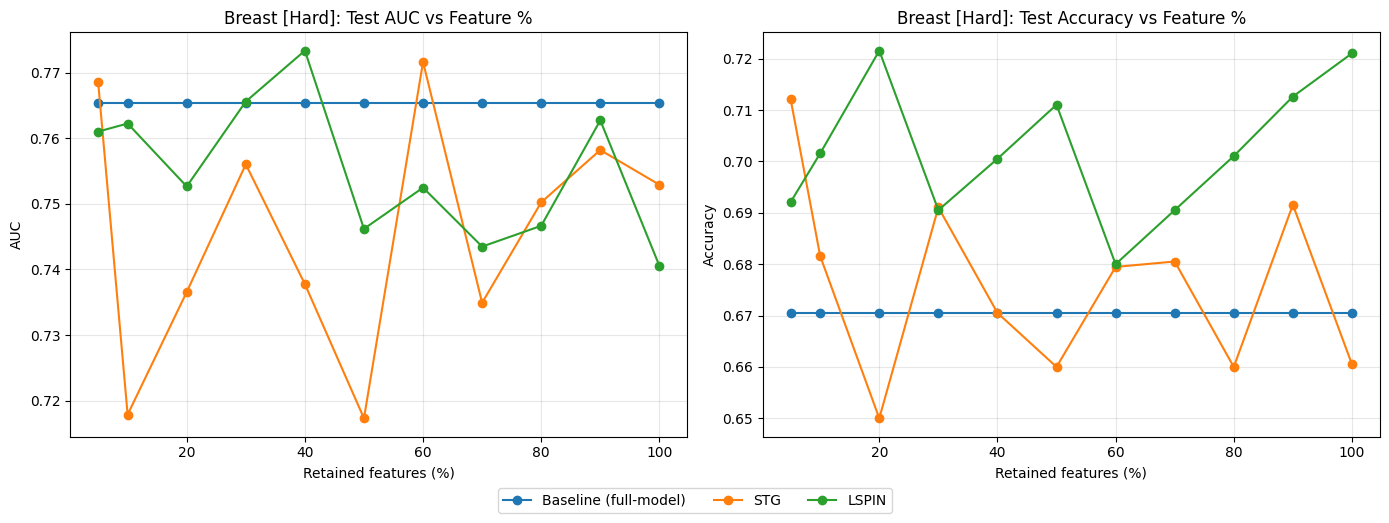

Saved train plot: /content/output/plots/Breast_train_curves.png


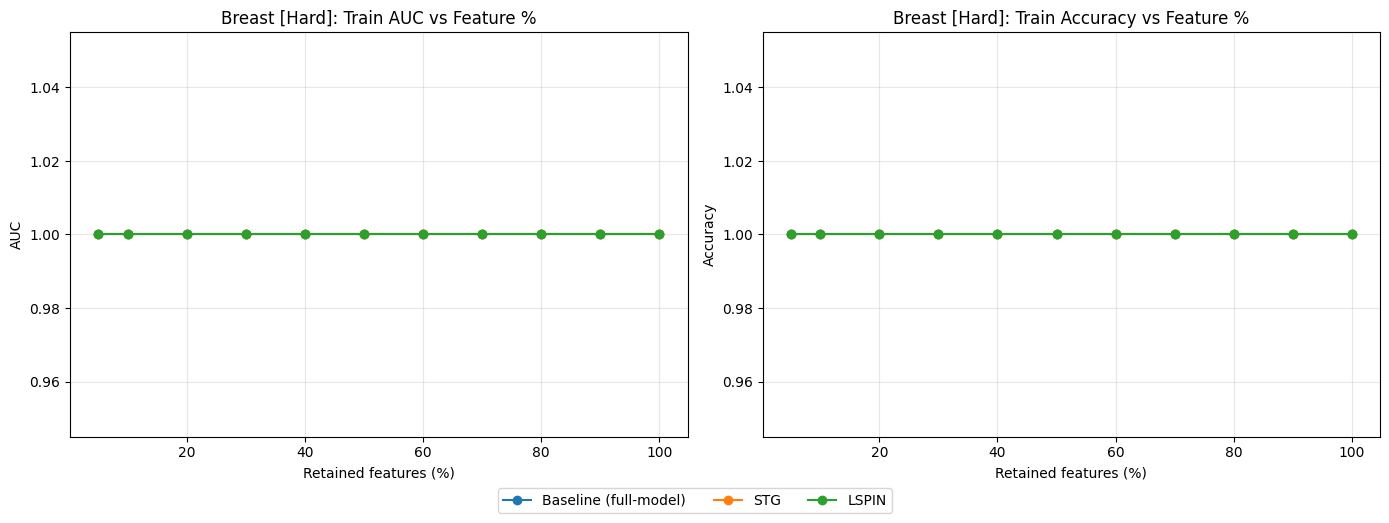

Saved test plot: /content/output/plots/RELATHE_test_curves.png


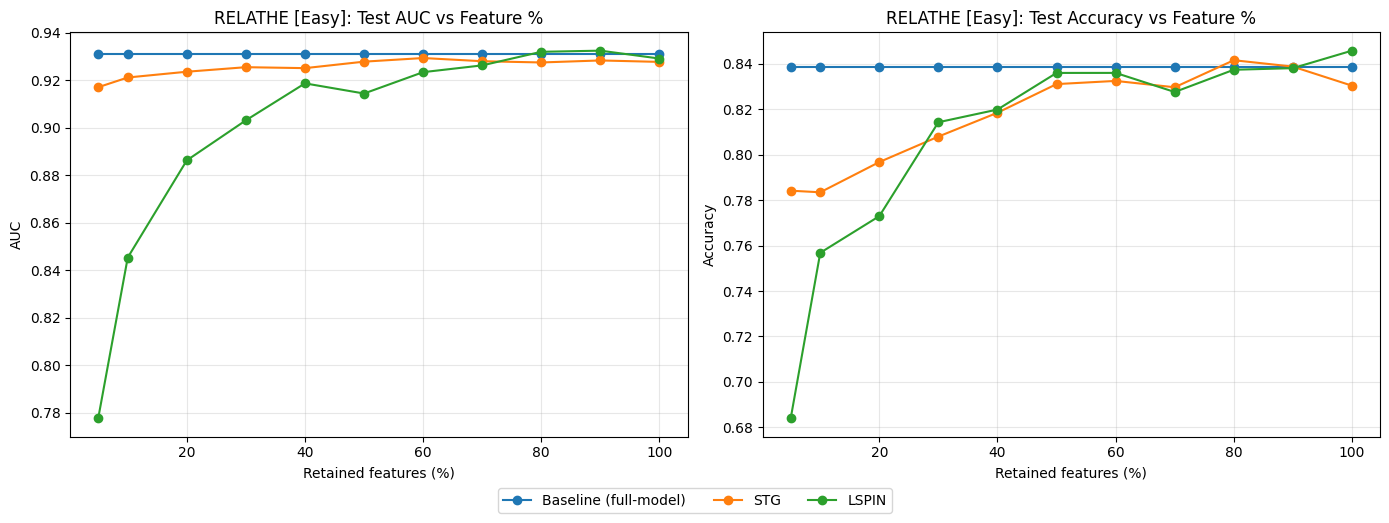

Saved train plot: /content/output/plots/RELATHE_train_curves.png


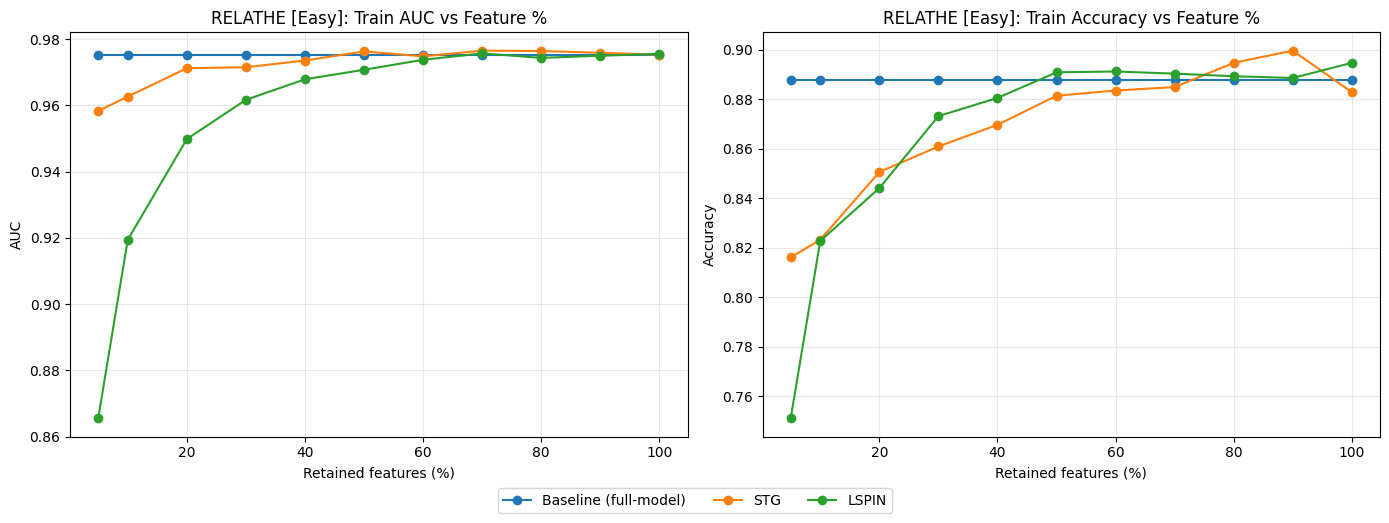

Saved test plot: /content/output/plots/SMK-CAN-187_test_curves.png


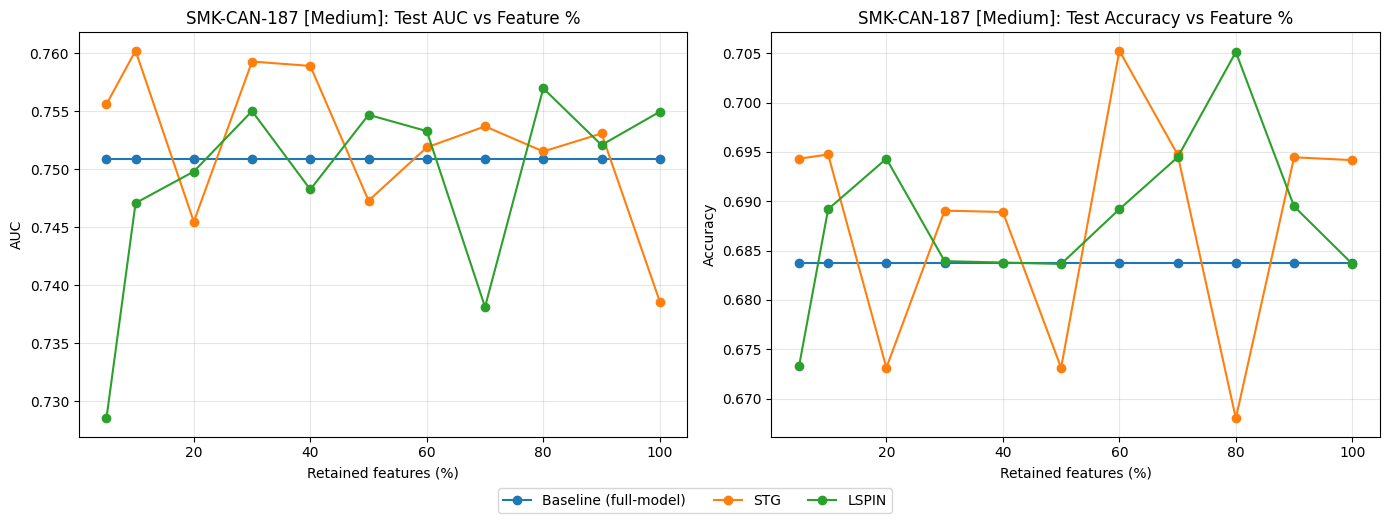

Saved train plot: /content/output/plots/SMK-CAN-187_train_curves.png


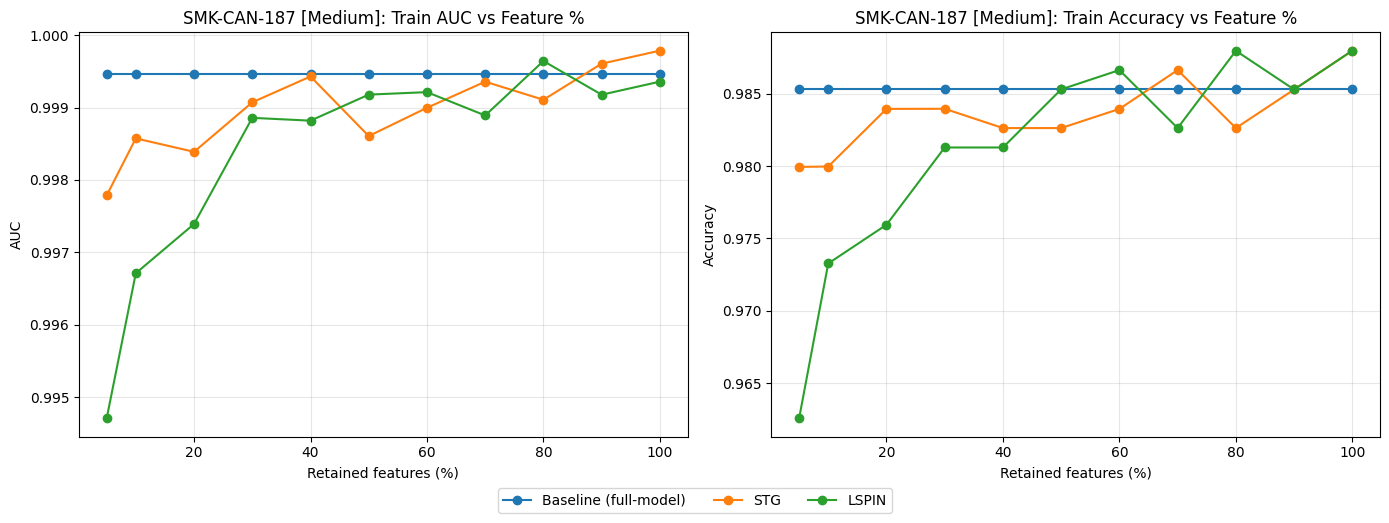

Saved test plot: /content/output/plots/colon_test_curves.png


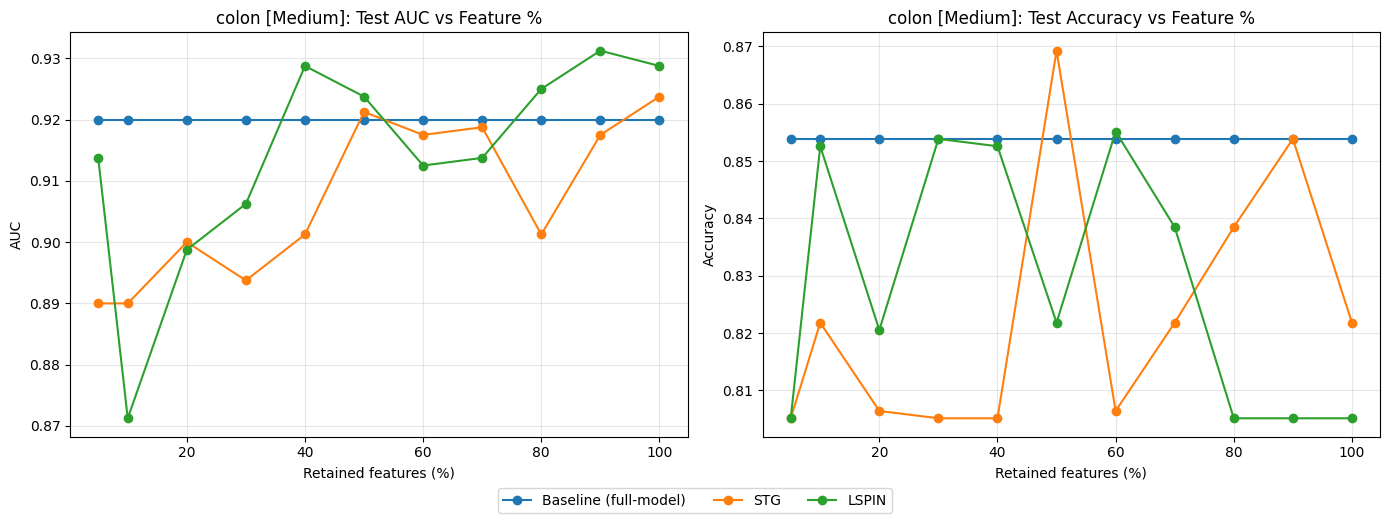

Saved train plot: /content/output/plots/colon_train_curves.png


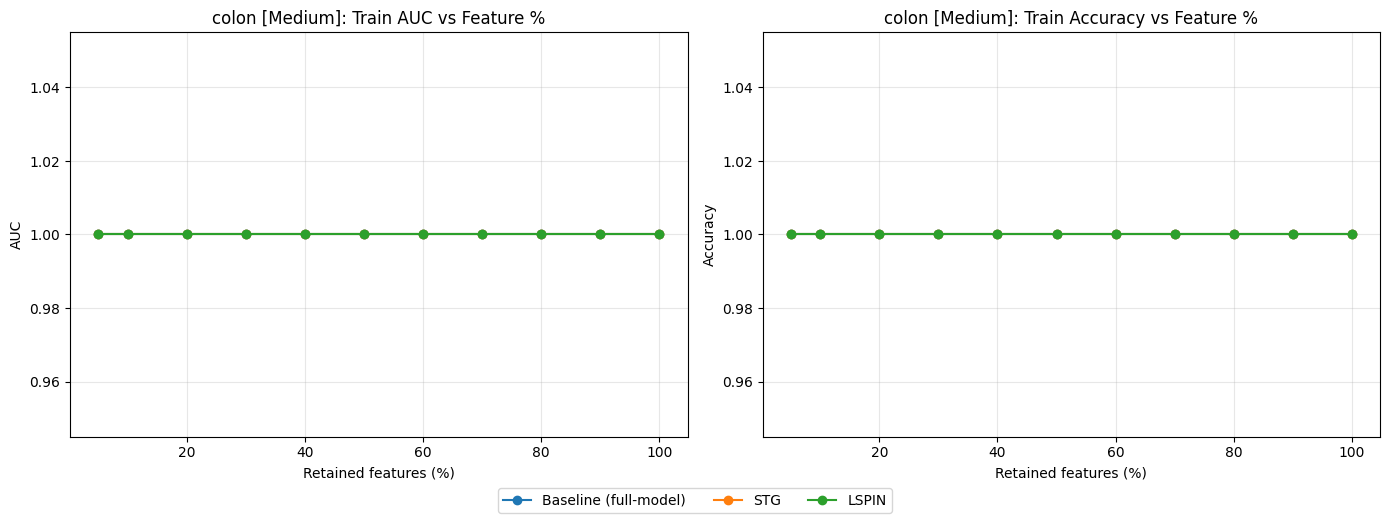

Saved test plot: /content/output/plots/leukemia_test_curves.png


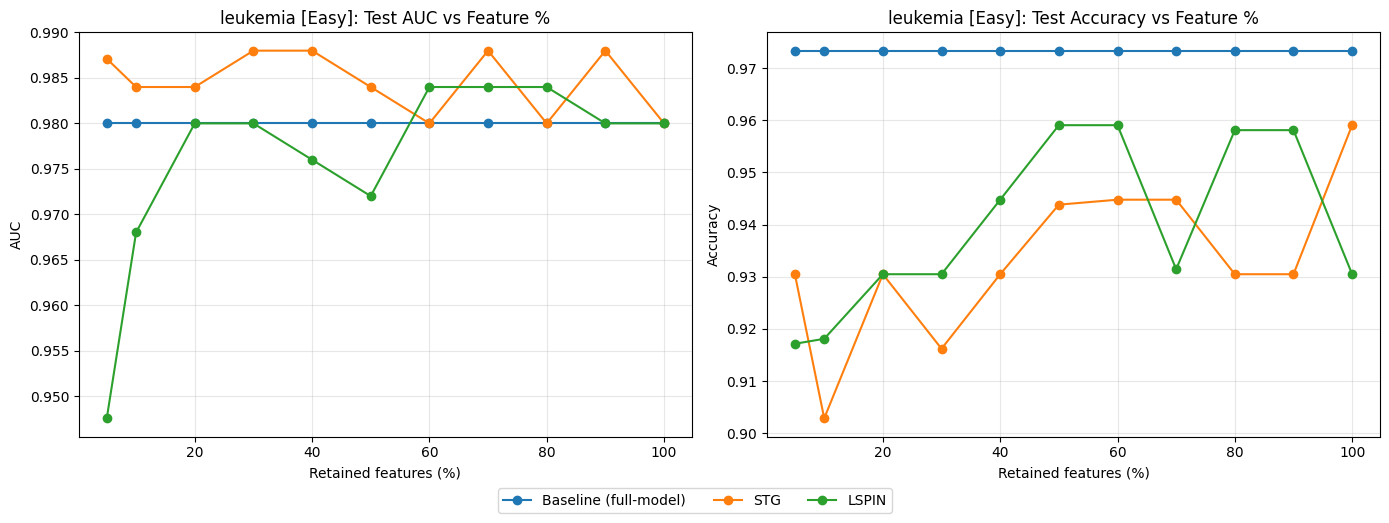

Saved train plot: /content/output/plots/leukemia_train_curves.png


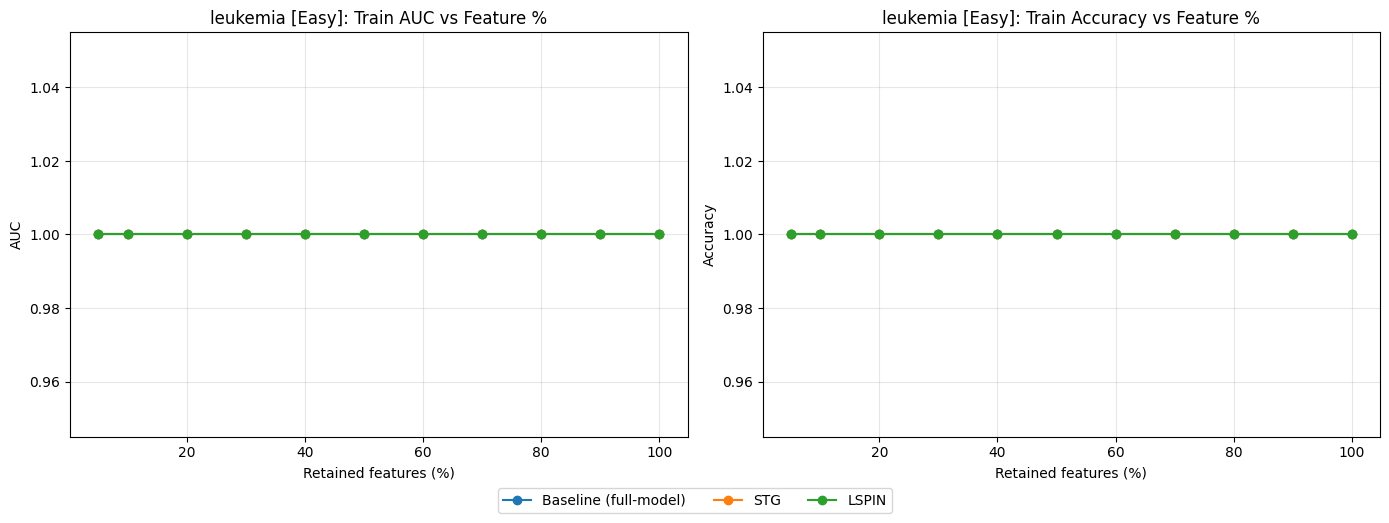

Saved test plot: /content/output/plots/madelon_test_curves.png


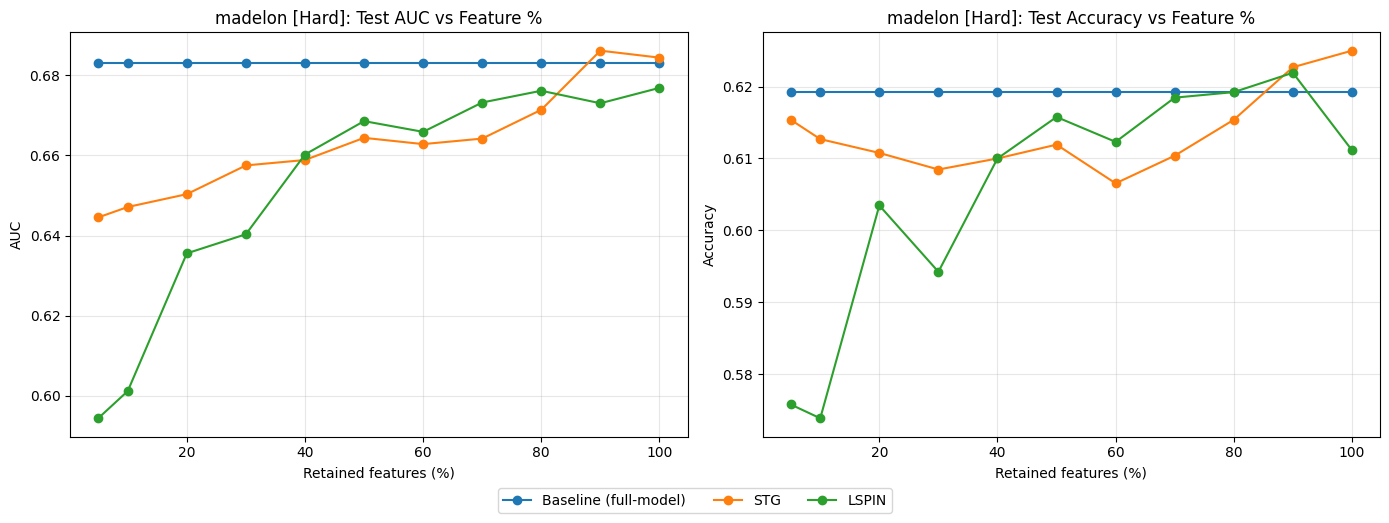

Saved train plot: /content/output/plots/madelon_train_curves.png


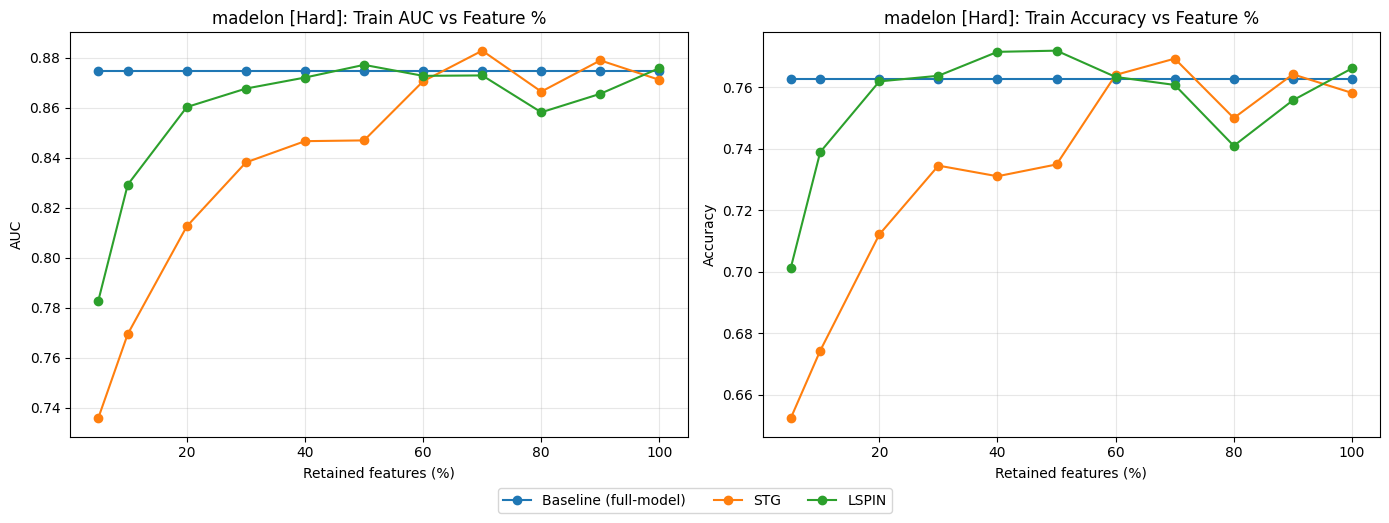

In [12]:
difficulty_by_dataset = {}
for idx, name in enumerate(DEFAULT_DATASET_NAMES):
    if idx < 2:
        difficulty_by_dataset[name] = "Hard"
    elif idx < 4:
        difficulty_by_dataset[name] = "Medium"
    else:
        difficulty_by_dataset[name] = "Easy"

plots_dir = OUTPUT_DIR / "plots"
plots_dir.mkdir(parents=True, exist_ok=True)

for dataset_name in sorted(combined_summary_df["dataset"].unique()):
    part = combined_summary_df[combined_summary_df["dataset"] == dataset_name].sort_values("feature_pct")
    difficulty = difficulty_by_dataset.get(dataset_name, "Unknown")

    # Test-set curves
    fig_test, axes_test = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

    axes_test[0].plot(part["feature_pct"], part["baseline_auc_mean"], marker="o", label=f"Baseline (full-model)")
    axes_test[0].plot(part["feature_pct"], part["stg_auc_mean"], marker="o", label=f"STG")
    axes_test[0].plot(part["feature_pct"], part["lspin_auc_mean"], marker="o", label=f"LSPIN")
    axes_test[0].set_title(f"{dataset_name} [{difficulty}]: Test AUC vs Feature %")
    axes_test[0].set_xlabel("Retained features (%)")
    axes_test[0].set_ylabel("AUC")
    axes_test[0].grid(True, alpha=0.3)

    axes_test[1].plot(part["feature_pct"], part["baseline_accuracy_mean"], marker="o", label=f"Baseline (full-model)")
    axes_test[1].plot(part["feature_pct"], part["stg_accuracy_mean"], marker="o", label=f"STG")
    axes_test[1].plot(part["feature_pct"], part["lspin_accuracy_mean"], marker="o", label=f"LSPIN")
    axes_test[1].set_title(f"{dataset_name} [{difficulty}]: Test Accuracy vs Feature %")
    axes_test[1].set_xlabel("Retained features (%)")
    axes_test[1].set_ylabel("Accuracy")
    axes_test[1].grid(True, alpha=0.3)

    handles_test, labels_test = axes_test[1].get_legend_handles_labels()
    fig_test.legend(handles_test, labels_test, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.05))
    fig_test.tight_layout()

    test_plot_path = plots_dir / f"{dataset_name}_test_curves.png"
    fig_test.savefig(test_plot_path, dpi=150, bbox_inches="tight")
    print(f"Saved test plot: {test_plot_path}")
    plt.show()

    # Train-set curves (only if present in summary columns)
    train_cols = {
        "baseline_train_auc_mean", "stg_train_auc_mean", "lspin_train_auc_mean",
        "baseline_train_accuracy_mean", "stg_train_accuracy_mean", "lspin_train_accuracy_mean",
    }
    if train_cols.issubset(part.columns):
        fig_train, axes_train = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

        axes_train[0].plot(part["feature_pct"], part["baseline_train_auc_mean"], marker="o", label=f"Baseline (full-model)")
        axes_train[0].plot(part["feature_pct"], part["stg_train_auc_mean"], marker="o", label=f"STG")
        axes_train[0].plot(part["feature_pct"], part["lspin_train_auc_mean"], marker="o", label=f"LSPIN")
        axes_train[0].set_title(f"{dataset_name} [{difficulty}]: Train AUC vs Feature %")
        axes_train[0].set_xlabel("Retained features (%)")
        axes_train[0].set_ylabel("AUC")
        axes_train[0].grid(True, alpha=0.3)

        axes_train[1].plot(part["feature_pct"], part["baseline_train_accuracy_mean"], marker="o", label=f"Baseline (full-model)")
        axes_train[1].plot(part["feature_pct"], part["stg_train_accuracy_mean"], marker="o", label=f"STG")
        axes_train[1].plot(part["feature_pct"], part["lspin_train_accuracy_mean"], marker="o", label=f"LSPIN")
        axes_train[1].set_title(f"{dataset_name} [{difficulty}]: Train Accuracy vs Feature %")
        axes_train[1].set_xlabel("Retained features (%)")
        axes_train[1].set_ylabel("Accuracy")
        axes_train[1].grid(True, alpha=0.3)

        handles_train, labels_train = axes_train[1].get_legend_handles_labels()
        fig_train.legend(handles_train, labels_train, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.05))
        fig_train.tight_layout()

        train_plot_path = plots_dir / f"{dataset_name}_train_curves.png"
        fig_train.savefig(train_plot_path, dpi=150, bbox_inches="tight")
        print(f"Saved train plot: {train_plot_path}")
        plt.show()
    else:
        print(f"Train-summary columns are missing for {dataset_name}; skipped train plot.")

## Write Outputs to Separate Files

All outputs are written to the output folder. The source ETree file is never modified.

In [13]:
summary_csv = OUTPUT_DIR / "iterative_feature_curve_summary.csv"
fold_csv = OUTPUT_DIR / "iterative_feature_curve_fold_results.csv"

combined_summary_df.to_csv(summary_csv, index=False)
combined_fold_df.to_csv(fold_csv, index=False)

print("Saved:")
print("-", summary_csv)
print("-", fold_csv)

Saved:
- /content/output/iterative_feature_curve_summary.csv
- /content/output/iterative_feature_curve_fold_results.csv


## Repeatable Execution Checks

Run this cell anytime to quickly re-check output artifacts without rerunning model training.

In [14]:
checks = {
    "summary_csv_exists": (OUTPUT_DIR / "iterative_feature_curve_summary.csv").exists(),
    "fold_csv_exists": (OUTPUT_DIR / "iterative_feature_curve_fold_results.csv").exists(),
}

check_df = pd.DataFrame([checks])
display(check_df)

if not all(checks.values()):
    raise RuntimeError("One or more repeatability checks failed.")

print("All repeatability checks passed.")

,summary_csv_exists,fold_csv_exists
0,True,True


All repeatability checks passed.
